In [3]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
import kagglehub

path = kagglehub.dataset_download(
   "amananandrai/ag-news-classification-dataset"
)

# Load CSV
print("Dataset path:",path)
print(os.listdir(path))

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.
Dataset path: /kaggle/input/ag-news-classification-dataset
['train.csv', 'test.csv']


In [6]:
import os
import pandas as pd

csv_file = os.path.join(path, 'train.csv')

df = pd.read_csv(csv_file, encoding="latin-1", header=None)


In [7]:
df.head()

,0,1,2
0,Class Index,Title,Description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...


In [8]:
print(df.shape)

(120001, 3)


In [9]:
df.columns = ["Class", "Title", "Description"]

In [10]:
df["Text"] = df["Title"] + " " + df["Description"]

In [11]:
df.head()

,Class,Title,Description,Text
0,Class Index,Title,Description,Title Description
1,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
2,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
3,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
4,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...


In [12]:
print(df.isnull().sum())

Class          0
Title          0
Description    0
Text           0
dtype: int64


In [13]:
df.dropna(inplace=True)

In [14]:
X = df["Text"]

In [17]:
# Combine title and description
df["Text"] = df["Title"] + " " + df["Description"]

# Features
X = df["Text"]

# Target
y = df["Class"]

In [18]:
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9080454981042456


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      6047
           2       0.95      0.98      0.97      5872
           3       0.88      0.87      0.87      6079
           4       0.89      0.88      0.89      6002
 Class Index       0.00      0.00      0.00         1

    accuracy                           0.91     24001
   macro avg       0.73      0.73      0.73     24001
weighted avg       0.91      0.91      0.91     24001



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
print(confusion_matrix(y_test, y_pred))

[[5424  194  284  145    0]
 [  50 5772   22   28    0]
 [ 224   63 5293  499    0]
 [ 223   46  428 5305    0]
 [   0    1    0    0    0]]


In [25]:
news = ["India won the cricket world cup after defeating Australia in the final."]

news_vector = tfidf.transform(news)

prediction = model.predict(news_vector)

print(prediction)

['2']


In [26]:
labels = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Science/Technology"
}

In [28]:
labels = {
    "1": "World",
    "2": "Sports",
    "3": "Business",
    "4": "Science/Technology"
}

print("Predicted Category:", labels[prediction[0]])

Predicted Category: Sports


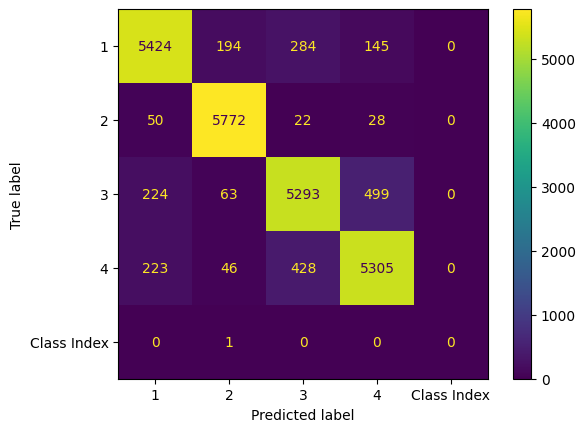

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()